In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
# 读取图片
img = plt.imread("../data/duck.jpg")
print("图片数据形状：", img.shape)

# 将图片数据转换为张量并改变形状
input = torch.tensor(img).permute(2, 0, 1).float()
print("输入特征图形状：", input.shape)

图片数据形状： (1080, 1080, 3)
输入特征图形状： torch.Size([3, 1080, 1080])


In [4]:
# 初始化卷积核
conv = torch.nn.Conv2d(in_channels=3, out_channels=3, kernel_size=9, stride=3, padding=0, bias=False)

In [5]:
# 对输入特征图进行卷积操作
output1 = conv(input)
print("卷积后输出特征图形状：", output1.shape)

卷积后输出特征图形状： torch.Size([3, 358, 358])


In [6]:
# 初始化池化层
pool = torch.nn.MaxPool2d(kernel_size=6, stride=6, padding=1)

In [7]:
# 进行池化操作
output2 = pool(output1)
print("池化后输出特征图形状：", output2.shape)

池化后输出特征图形状： torch.Size([3, 60, 60])


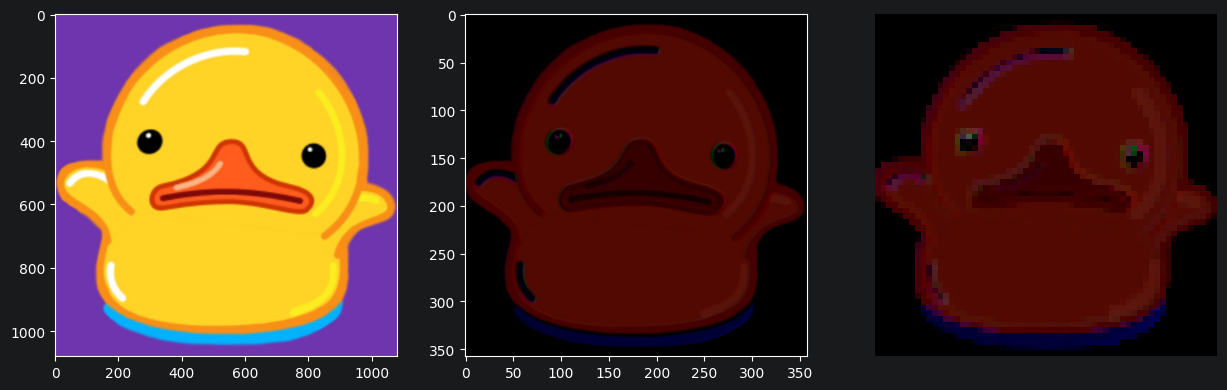

In [8]:
# 将输出特征图转换为图片
output1 = torch.clamp(output1.int(), 0, 255) # 限制输出在0到255之间
output1 = output1.permute(1, 2, 0).detach().numpy()
output2 = torch.clamp(output2.int(), 0, 255) # 限制输出在0到255之间
output2 = output2.permute(1, 2, 0).detach().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img)
ax[1].imshow(output1)
ax[2].imshow(output2)
plt.axis("off")
plt.show()